In [1]:
import numpy as np
import pandas as pd
import torch
from seaborn import kdeplot
from sbi.utils import get_kde, KDEWrapper, BoxUniform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore', Warning)

import sys
sys.path.insert(1, '../../collective_posterior/')
from collective_posterior import CollectivePosterior

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

change_font(16)

[Text(-8.0, 0, '0.0'),
 Text(-6.0, 0, '0.002'),
 Text(-4.0, 0, '0.018'),
 Text(-2.0, 0, '0.135'),
 Text(0.0, 0, '1.0'),
 Text(2.0, 0, '7.389'),
 Text(4.0, 0, '54.598')]

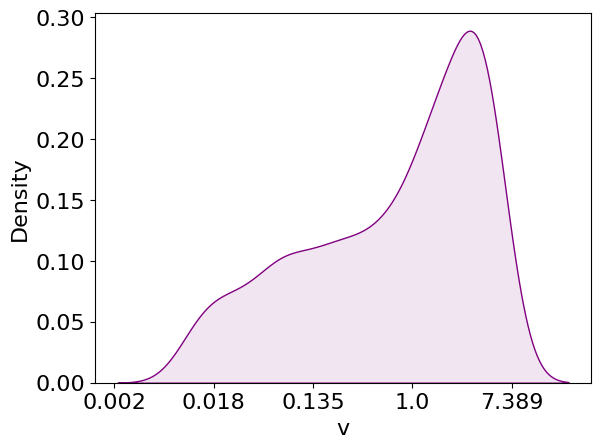

In [2]:
fig, ax = plt.subplots()
results_df = pd.read_csv('abcout13.csv', dtype='float')
y = results_df.iloc[:,6]
kdeplot(y, fill=True, color='purple', alpha=0.1)
ax.set_xticklabels([round(np.e**float(a),3) for a in ax.get_xticks()])
# ax.axvline(np.log(5), color='k', ls = '--')

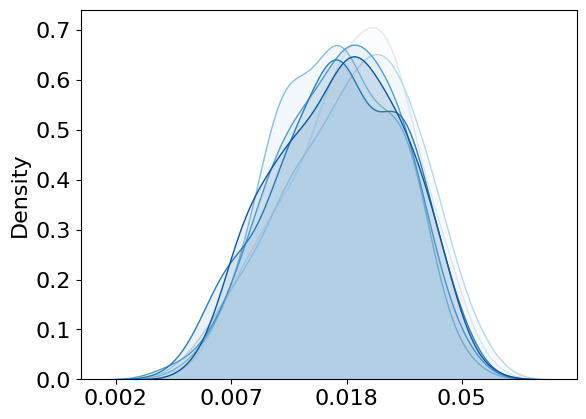

In [3]:
fig, ax = plt.subplots()
p = sns.color_palette("Blues", 6)
kdes = []
total_sims = pd.DataFrame()
for i in range(6):
    df_pop = results_df.iloc[:,12+10*i:22+10*i]
    df_pop.loc[:,'dist'] = (df_pop.iloc[:,-10:]**2).sum(1)
    eps = df_pop['dist'].quantile(0.2)
    df_pop = df_pop[df_pop['dist']<eps]
    k = results_df.iloc[df_pop.index, 6:11]
    total_sims = pd.concat([total_sims, k], axis=0)
    r = torch.tensor(np.array(k))
    kde = get_kde(r)
    kdes.append(kde)

    kdeplot(r[:,4], fill=True, alpha=0.1, ax=ax, color = p[i])
    ax.set_xticklabels([round(np.e**float(a),3) for a in ax.get_xticks()])    

In [4]:
len(total_sims.drop_duplicates())

735

In [5]:
low = torch.tensor([-4.6, 0.01, -1.39, 0.92, -9.2])
high = torch.tensor([1.61, 1, 1.39, 3.92, -1.2])
prior = BoxUniform(low=low, high=high)

In [6]:
cp = CollectivePosterior(posterior_list=[kde.log_prob for kde in kdes], prior=prior, Xs = [i for i in range(6)], log_C=42, epsilon=-5000, n_eval=10000)

In [7]:
cp.get_log_C()

tensor(363.7960)

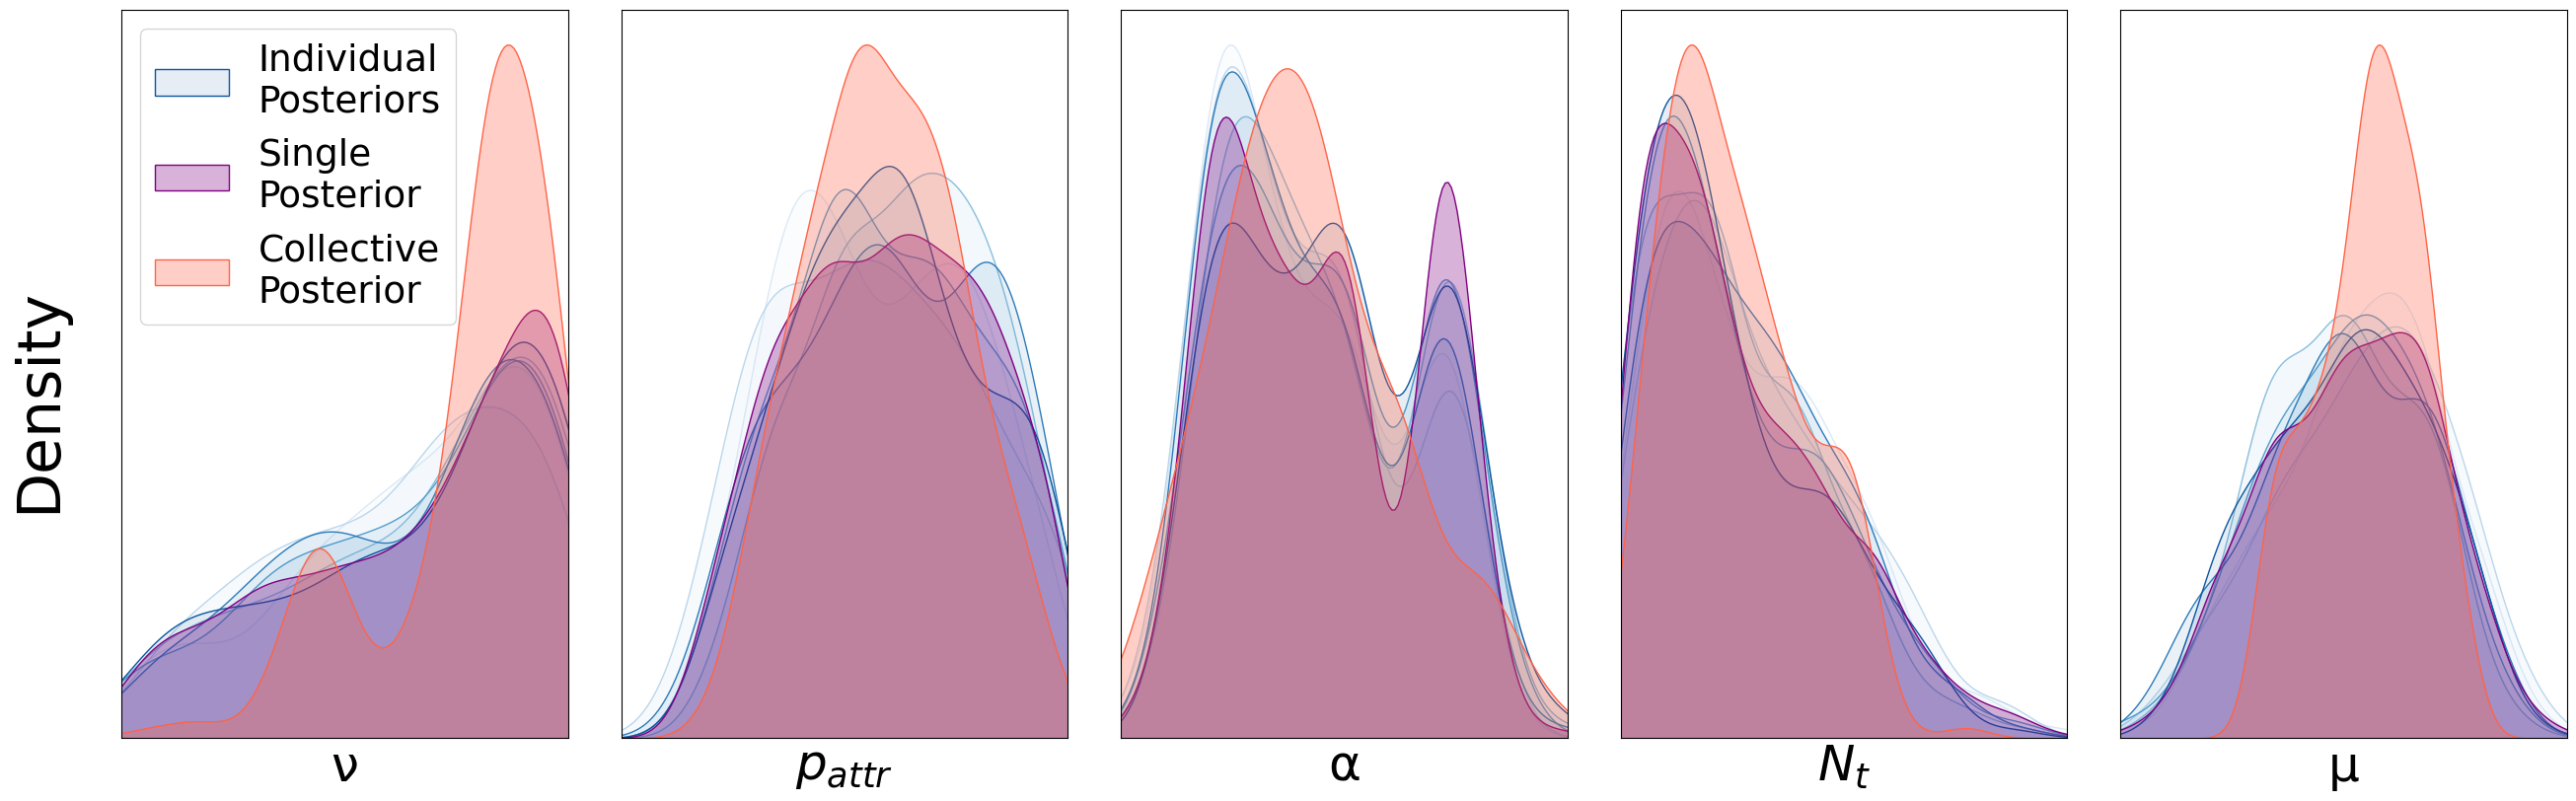

In [26]:
change_font(36)
fig, ax = plt.subplots(1,5, figsize=(27,9), tight_layout=True)
labels = ['ν', '$p_{attr}$', 'α', '$N_t$', 'μ']
# samps = cp.sample(200)
params_df = results_df.iloc[:,6:11]
for n in range(5):
    ax[n].set_xlim(prior.base_dist.low[n], prior.base_dist.high[n])
    
    for i in range(6):
        df_pop = results_df.iloc[:,12+10*i:22+10*i]
        df_pop.loc[:,'dist'] = (df_pop.iloc[:,-10:]**2).sum(1)
        eps = df_pop['dist'].quantile(0.2)
        df_pop = df_pop[df_pop['dist']<eps]
        k = params_df.iloc[df_pop.index, :]
        r = torch.tensor(np.array(k))
        kdeplot(r[:,n], fill=True, alpha=0.1, ax=ax[n], color = p[i], label = 'Individual\nPosteriors' if i==5 and n==0 else '')
    
    y = params_df.iloc[:,n]
    kdeplot(y, fill=True, color='purple', alpha=0.3, label = 'Single\nPosterior' if n==0 else '', ax=ax[n])
    
    kdeplot(samps[:,n], color='tomato', label = 'Collective\nPosterior' if n==0 else '', fill=True, alpha=0.3, ax=ax[n])


    if n in [2,4]:
        minmin = min(samps[:,n].min().item(), r[:,n].min(), y.min())
        maxmax = max(samps[:,n].max().item(), r[:,n].max(), y.max())
        ax[n].set_xlim(minmin, maxmax)
        
    ax[n].set_xlabel(labels[n])
    ax[n].set_yticks([])
    ax[n].set_xticks([])
    ax[n].set_ylabel('')
    if n != 1:
        ax[n].set_xticklabels([round(torch.e**float(a),3) for a in ax[n].get_xticks()])
fig.supylabel('Density')
ax[0].legend(loc='upper left', fontsize=27)
